# BUPA Liver Disorders - MLP (PyTorch)
Uses `selector` as target for demonstration.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   mcv  alkphos  sgpt  sgot  gammagt  drinks  selector
0   85       92    45    27       31     0.0         1
1   85       64    59    32       23     0.0         2
2   86       54    33    16       54     0.0         2
3   91       78    34    24       36     0.0         2
4   87       70    12    28       10     0.0         2
(345, 7)


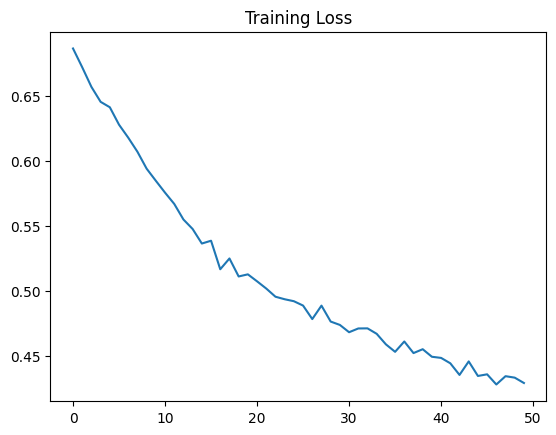

Accuracy: 0.7681159420289855
              precision    recall  f1-score   support

           0       0.76      0.66      0.70        29
           1       0.77      0.85      0.81        40

    accuracy                           0.77        69
   macro avg       0.77      0.75      0.76        69
weighted avg       0.77      0.77      0.77        69

[[19 10]
 [ 6 34]]
Model saved.


In [2]:
!pip -q install ucimlrepo torch scikit-learn matplotlib seaborn


import pandas as pd, numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
import torch
from torch import nn
from torch.utils.data import TensorDataset,DataLoader
import matplotlib.pyplot as plt

# ==========================================
# MOUNT GOOGLE DRIVE
# ==========================================

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

# ==========================================
# PATH DU DATASET
# Modifie seulement cette ligne
# ==========================================

DATA_PATH = "/content/drive/MyDrive/liver+disorders/bupa.data"

# ==========================================
# NOMS DES COLONNES
# ==========================================

columns = [
    "mcv",
    "alkphos",
    "sgpt",
    "sgot",
    "gammagt",
    "drinks",
    "selector"
]

# ==========================================
# LECTURE DU DATASET
# ==========================================

df = pd.read_csv(DATA_PATH, names=columns)

print(df.head())
print(df.shape)

# ==========================================
# FEATURES / TARGET
# ==========================================

X = df.drop("selector", axis=1)

# Transformer 1/2 -> 0/1
y = df["selector"].astype(int) - 1

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

Xtr=torch.tensor(X_train,dtype=torch.float32)
Xte=torch.tensor(X_test,dtype=torch.float32)
ytr=torch.tensor(y_train.values,dtype=torch.long)
yte=torch.tensor(y_test.values,dtype=torch.long)
train_loader=DataLoader(TensorDataset(Xtr,ytr),batch_size=32,shuffle=True)

class MLP(nn.Module):
    def __init__(self,n):
        super().__init__()
        self.net=nn.Sequential(
            nn.Linear(n,64),nn.ReLU(),
            nn.Linear(64,32),nn.ReLU(),
            nn.Linear(32,2))
    def forward(self,x): return self.net(x)

model=MLP(Xtr.shape[1])
opt=torch.optim.Adam(model.parameters(),lr=1e-3)
loss_fn=nn.CrossEntropyLoss()
losses=[]
for epoch in range(50):
    model.train(); tot=0
    for xb,yb in train_loader:
        opt.zero_grad()
        out=model(xb)
        loss=loss_fn(out,yb)
        loss.backward(); opt.step()
        tot+=loss.item()
    losses.append(tot/len(train_loader))
plt.plot(losses); plt.title("Training Loss"); plt.show()

model.eval()
with torch.no_grad():
    pred=model(Xte).argmax(1).numpy()
print("Accuracy:",accuracy_score(y_test,pred))
print(classification_report(y_test,pred))
print(confusion_matrix(y_test,pred))
torch.save(model.state_dict(),"mlp_bupa.pth")
print("Model saved.")


In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file.endswith(".data"):
            print(os.path.join(root, file))

Mounted at /content/drive
/content/drive/MyDrive/liver+disorders/bupa.data
